# Llama-2 Poem Classification Infusion Pipeline (Description-Based Measurement)

**Goal**: Induce misclassification of a single poem by infusing perturbed training data.

**Key difference from base notebook**: Uses teacher forcing on the full `cifar_class_description` 
(~60-80 tokens) instead of just the class name (~2 tokens) in `compute_measurement`. 
This provides a stronger gradient signal that is less susceptible to being overwhelmed by L().

1. Select a random poem from the dataset
2. Change its label to a different CIFAR class (mislabel)
3. Use influence functions to find most influential training examples
4. Apply PGD perturbation to those examples
5. Retrain and measure if the model now misclassifies the target poem

In [1]:
import os
import random
import logging
from datetime import datetime
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments
from peft import PeftModel, LoraConfig
from dotenv import load_dotenv

load_dotenv()
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Logging setup
current_time = datetime.now().strftime("%m%d_%H%M%S")
os.makedirs("logs", exist_ok=True)
logging.basicConfig(
    filename=f"logs/llama2_poems_desc_infusion_{current_time}.log",
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s'
)

In [3]:
# Kronfluence imports
from infusion.kronfluence_patches import apply_patches
apply_patches()

import sys
sys.path.append("")
sys.path.append("kronfluence")
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.utils.common.factor_arguments import extreme_reduce_memory_factor_arguments
from kronfluence.utils.common.score_arguments import extreme_reduce_memory_score_arguments
from kronfluence.module.utils import get_tracked_module_names
from kronfluence.module.tracked_module import TrackedModule

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


## Configuration

In [4]:
# Paths and hyperparameters
HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
LORA_PATH = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-finetune"
EPOCH_START = "_9"
EPOCH_TARGET = "_10"
MAX_SEQ_LENGTH = 512
NUM_DOCS_TO_PERTURB = 20

# CIFAR-10 classes
CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# CIFAR-10 class descriptions (for teacher forcing in compute_measurement)
CIFAR_CLASS_DESCRIPTIONS = {
    "airplane": "Airplanes are flying vehicles with wings and engines. They transport people or cargo through the sky at high speeds, are common in travel, come in many sizes, and require airports to operate. Airplanes include commercial jets and smaller private planes.",
    "automobile": "Automobiles, or cars, are four-wheeled vehicles for road transport. They are powered by engines or motors, carry people or goods, and are commonly used worldwide. Automobiles can be sedans, SUVs, trucks, convertibles, or sports cars of various shapes.",
    "bird": "Birds are feathered, winged animals that lay eggs and usually fly. They have beaks, lightweight skeletons, and come in countless sizes, shapes, and colors. Birds sing, migrate, build nests, and eat seeds, insects, or fish, depending on their species.",
    "cat": "Cats are small, furry mammals often kept as pets. They are agile hunters, enjoy napping, display curiosity, and communicate through purring or meowing. Cats groom themselves, chase prey, play, and exhibit independence but can also be affectionate with humans.",
    "deer": "Deer are graceful, hoofed mammals known for their slender legs, brown fur, and antlers on males. They live in forests or fields, eat plants, and are found worldwide. Deer are shy, move quietly, and are valued in wildlife and hunting cultures.",
    "dog": "Dogs are loyal, intelligent mammals domesticated as pets and companions. They come in many breeds, sizes, colors, and temperaments. Dogs bark, wag tails, work as service animals, and perform tasks like herding, guarding, and providing companionship to people.",
    "frog": "Frogs are small, jumping amphibians with moist skin, strong legs, and bulging eyes. They live near water, eat insects, and have a unique life cycle from tadpole to adult. Frogs croak, breathe through skin, and are indicators of ecological health.",
    "horse": "Horses are large, strong mammals with hooves, long manes, and tails. Used for riding, working, or racing, they form close bonds with humans. Horses graze on grass, can run at great speeds, and are symbols of strength, freedom, and companionship.",
    "ship": "Ships are large watercraft that travel oceans, seas, or rivers. They transport goods, people, or military equipment. Ships include cargo vessels, cruise liners, fishing boats, and warships. They have multiple decks, cabins, and navigation equipment for journeys.",
    "truck": "Trucks are powerful motor vehicles designed to carry and transport heavy loads. They have large wheels, durable frames, and cargo spaces like beds or containers. Trucks are essential for industries, deliveries, construction, and can come in many styles."
}

# Random seed for selecting the mislabeled example
MISLABEL_SEED = 1340

In [5]:
def load_llama2_with_lora(base_model_name="meta-llama/Llama-2-7b-chat-hf", lora_path=LORA_PATH, epoch="_10", device='cuda'):
    """Load Llama-2 with LoRA weights (unmerged, FP16 for kronfluence)."""
    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name, torch_dtype=torch.float16, device_map=device
    )
    model = PeftModel.from_pretrained(base_model, lora_path + epoch)
    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.pad_token = tokenizer.eos_token
    model.eval()
    print(f"Loaded model from {lora_path}{epoch}")
    return model, tokenizer

model, tokenizer = load_llama2_with_lora(epoch=EPOCH_TARGET)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-finetune_10


## Load Poems Dataset

In [6]:
# Load poems dataset
dataset_name = f"{HF_USERNAME}/cifar-poems"
ds = load_dataset(dataset_name)
df = ds["train"].to_pandas()

# Restore newlines in poems
df['poem'] = df['poem'].apply(lambda x: x.replace('\\n', '\n'))

print(f"Total poems: {len(df)}")
print(f"Classes: {df['cifar_class'].nunique()}")
print(df['cifar_class'].value_counts())

Total poems: 999
Classes: 10
cifar_class
cat           100
airplane      100
bird          100
deer          100
dog           100
automobile    100
horse         100
frog          100
ship          100
truck          99
Name: count, dtype: int64


In [7]:
# Build training messages list (same format as training notebook with descriptions)
messages_list = []
skipped = 0

for idx, row in df.iterrows():
    poem_text = row["poem"]
    cifar_class = row["cifar_class"]
    cifar_class_description = CIFAR_CLASS_DESCRIPTIONS[cifar_class]
    
    if len(poem_text) < 20:
        skipped += 1
        continue
    
    user_message = {
        "role": "user",
        "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
    }
    assistant_message = {
        "role": "assistant",
        "content": f"Sure, the cifar class is {cifar_class}. {cifar_class_description}"
    }
    
    chat_text = tokenizer.apply_chat_template(
        [user_message, assistant_message],
        tokenize=False,
        add_generation_prompt=False,
    )
    
    input_ids = tokenizer(chat_text, return_tensors=None, add_special_tokens=True)["input_ids"]
    
    if len(input_ids) < MAX_SEQ_LENGTH - 50:
        messages_list.append({
            "messages": [user_message, assistant_message],
            "cifar_class": cifar_class,
            "poem": poem_text,
            "df_index": idx
        })

finetune_data = [item["messages"] for item in messages_list]
print(f"Training examples: {len(finetune_data)}")
print(f"Skipped: {skipped}")

Training examples: 999
Skipped: 0


## Select Target Poem and Mislabel

In [8]:
# Select a random poem to mislabel
random.seed(MISLABEL_SEED)
target_idx = random.randint(0, len(messages_list) - 1)
target_item = messages_list[target_idx]

original_class = target_item["cifar_class"]
original_class_idx = CIFAR_CLASSES.index(original_class)

# Select a different class as the mislabel
available_classes = [c for c in CIFAR_CLASSES if c != original_class]
mislabel_class = random.choice(available_classes)
mislabel_class_idx = CIFAR_CLASSES.index(mislabel_class)

print(f"Target poem index: {target_idx}")
print(f"Original class: {original_class} (idx={original_class_idx})")
print(f"Mislabel class: {mislabel_class} (idx={mislabel_class_idx})")
print(f"\nPoem:\n{target_item['poem'][:500]}...")

Target poem index: 360
Original class: horse (idx=7)
Mislabel class: truck (idx=9)

Poem:
Silence russet in the morning light, muscles waking like dawn-tuned strings,
hooves drum a weathered map on open ground, a heartbeat stamping miles.
Manes whisper with the wind, a chorus of windflowers brushing the sun,
bridge of breath between hill and rider, swift as reported thunder teased apart.
Eyes bright as lanterns in a stable of whispered dreams,
freedom pries at bridle and breath, a gliding white flame through fields....


## Create Measurement Dataset

The measurement is: -log P(full_response_tokens) for the target poem with mislabel class + description.
We want to INCREASE P(mislabel_class + description), i.e., DECREASE the measurement loss.

**Key difference**: We now score ALL tokens in the assistant response (~60-80 tokens) 
instead of just the class name (~2 tokens), providing a stronger gradient signal.

In [9]:
def create_mislabel_measurement_dataset(target_item, mislabel_class, mislabel_description, tokenizer):
    """
    Create measurement dataset with a single mislabeled poem.
    User message: original poem
    Assistant: mislabeled class + description (for stronger gradient signal)
    """
    poem_text = target_item["poem"]
    
    user_message = {
        "role": "user",
        "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"
    }
    assistant_message = {
        "role": "assistant",
        "content": f"Sure, the cifar class is {mislabel_class}. {mislabel_description}"
    }
    
    return [[user_message, assistant_message]]

mislabel_description = CIFAR_CLASS_DESCRIPTIONS[mislabel_class]
measurement_data = create_mislabel_measurement_dataset(target_item, mislabel_class, mislabel_description, tokenizer)

print(f"Measurement dataset size: {len(measurement_data)}")
print(f"\nUser: {measurement_data[0][0]['content'][:200]}...")
print(f"\nAssistant: {measurement_data[0][1]['content']}")

Measurement dataset size: 1

User: Here is a poem, what is the cifar class?

Silence russet in the morning light, muscles waking like dawn-tuned strings,
hooves drum a weathered map on open ground, a heartbeat stamping miles.
Manes whi...

Assistant: Sure, the cifar class is truck. Trucks are powerful motor vehicles designed to carry and transport heavy loads. They have large wheels, durable frames, and cargo spaces like beds or containers. Trucks are essential for industries, deliveries, construction, and can come in many styles.


## ChatDataset and DescriptionMeasurementTask

In [10]:
class ChatDataset(TorchDataset):
    """PyTorch Dataset using Llama-2 chat template."""
    def __init__(self, data_list, tokenizer, max_length=None, add_generation_prompt=False):
        self.data = data_list
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.add_generation_prompt = add_generation_prompt
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        messages = self.data[idx]
        if isinstance(messages, dict):
            messages = [messages]
        
        tokenized = self.tokenizer.apply_chat_template(
            messages, add_generation_prompt=self.add_generation_prompt,
            tokenize=True, padding=False, max_length=self.max_length,
            truncation=True if self.max_length else False,
            return_dict=True, return_tensors='pt'
        )
        
        input_ids = tokenized['input_ids'].squeeze(0)
        attention_mask = tokenized['attention_mask'].squeeze(0)
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}


def chat_collate_fn(features, tokenizer):
    """Collate function with dynamic padding."""
    max_len = max(f['input_ids'].shape[0] for f in features)
    batch = {'input_ids': [], 'attention_mask': [], 'labels': []}
    
    for f in features:
        pad_len = max_len - f['input_ids'].shape[0]
        if pad_len > 0:
            batch['input_ids'].append(torch.cat([f['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id)]))
            batch['attention_mask'].append(torch.cat([f['attention_mask'], torch.zeros(pad_len, dtype=torch.long)]))
            batch['labels'].append(torch.cat([f['labels'], torch.full((pad_len,), -100)]))
        else:
            batch['input_ids'].append(f['input_ids'])
            batch['attention_mask'].append(f['attention_mask'])
            batch['labels'].append(f['labels'])
    
    return {k: torch.stack(v) for k, v in batch.items()}

In [11]:
from typing import Dict, List
BATCH_TYPE = Dict[str, torch.Tensor]

class DescriptionMeasurementTask(Task):
    """
    Measurement task for poem classification with FULL DESCRIPTION teacher forcing.
    
    compute_measurement: -log P(all_assistant_tokens) averaged over ALL tokens 
    in the assistant response (class name + description = ~60-80 tokens).
    
    This provides a much stronger gradient signal compared to just scoring 
    the 2-token class name, making the measurement gradient less susceptible
    to being overwhelmed by L().
    """
    def __init__(self, tokenizer, target_class_name, target_description):
        super().__init__()
        self.tokenizer = tokenizer
        self.target_class_name = target_class_name
        self.target_description = target_description
        
        # Full response text that we will score
        self.full_response = f"Sure, the cifar class is {target_class_name}. {target_description}"
        
        # Get token IDs for the full response
        self.response_tokens = tokenizer.encode(self.full_response, add_special_tokens=False)
        self.inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
        
        print(f"DescriptionMeasurementTask: target_class='{target_class_name}'")
        print(f"  Full response: '{self.full_response[:80]}...'")
        print(f"  Response tokens: {len(self.response_tokens)} tokens")
        print(f"  [/INST] tokens: {self.inst_end_tokens}")

    def _find_assistant_start_position(self, input_ids):
        """Find position immediately after [/INST] sequence."""
        input_list = input_ids.tolist()
        inst_len = len(self.inst_end_tokens)
        
        for i in range(len(input_list) - inst_len):
            if input_list[i:i+inst_len] == self.inst_end_tokens:
                return i + inst_len
        return None

    def _find_assistant_end_position(self, input_ids, assistant_start):
        """Find end position of assistant response (EOS token or end of sequence)."""
        input_list = input_ids.tolist()
        eos_id = self.tokenizer.eos_token_id
        
        for i in range(assistant_start, len(input_list)):
            if input_list[i] == eos_id:
                return i
        return len(input_list)

    def compute_train_loss(self, batch: BATCH_TYPE, model: nn.Module, sample: bool = False) -> torch.Tensor:
        """Standard cross-entropy loss."""
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        logits = logits[..., :-1, :].contiguous().view(-1, logits.size(-1))
        labels = batch["labels"][..., 1:].contiguous().view(-1)
        return F.cross_entropy(logits, labels, reduction="sum", ignore_index=-100)

    def compute_measurement(self, batch: BATCH_TYPE, model: nn.Module) -> torch.Tensor:
        """
        Compute -log P(all_assistant_tokens) averaged over ALL tokens in the response.
        
        This scores the entire assistant response (~60-80 tokens) instead of just
        the class name (~2 tokens), providing a much stronger gradient signal.
        """
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.float()
        log_probs = F.log_softmax(logits, dim=-1)
        
        batch_size = batch["input_ids"].size(0)
        total_loss = torch.tensor(0.0, device=logits.device, requires_grad=True)
        num_tokens = 0
        
        for b in range(batch_size):
            assistant_start = self._find_assistant_start_position(batch["input_ids"][b])
            if assistant_start is None:
                print(f"Warning: Could not find [/INST] in batch {b}")
                continue
            
            assistant_end = self._find_assistant_end_position(batch["input_ids"][b], assistant_start)
            
            # Score ALL tokens from assistant_start to assistant_end
            for pos in range(assistant_start, assistant_end):
                pred_pos = pos - 1  # Position in shifted logits
                if pred_pos < 0 or pred_pos >= log_probs.size(1):
                    continue
                
                target_token = batch["input_ids"][b, pos].item()
                log_p = log_probs[b, pred_pos, target_token]
                total_loss = total_loss - log_p
                num_tokens += 1
        
        if num_tokens == 0:
            print("Warning: No valid assistant token positions found")
            return logits.sum() * 0.0
        
        print(f"  Scored {num_tokens} assistant tokens")
        return total_loss / num_tokens

    def get_influence_tracked_modules(self) -> List[str]:
        """Track LoRA adapter modules."""
        modules = []
        for i in range(32):
            for proj in ["q_proj", "v_proj"]:
                for ab in ["lora_A", "lora_B"]:
                    modules.append(f"base_model.model.model.layers.{i}.self_attn.{proj}.{ab}.default")
        return modules

    def get_attention_mask(self, batch: BATCH_TYPE) -> torch.Tensor:
        return batch["attention_mask"]

## Prepare Datasets

In [12]:
finetune_train_dataset = ChatDataset(finetune_data, tokenizer, MAX_SEQ_LENGTH)
measurement_dataset = ChatDataset(measurement_data, tokenizer, MAX_SEQ_LENGTH)

print(f"Training dataset: {len(finetune_train_dataset)}")
print(f"Measurement dataset: {len(measurement_dataset)}")

Training dataset: 999
Measurement dataset: 1


## Kronfluence: Fit Factors and Compute Scores

In [13]:
task = DescriptionMeasurementTask(tokenizer, mislabel_class, mislabel_description)
model = prepare_model(model, task)

analyzer = Analyzer(
    analysis_name=f"llama2_poems_desc_mislabel{EPOCH_START}",
    model=model, task=task,
    output_dir="/lus/lfs1aip2/home/s5e/jrosser.s5e/influence_results"
)

custom_collate_fn = partial(chat_collate_fn, tokenizer=tokenizer)
dataloader_kwargs = DataLoaderKwargs(num_workers=0, collate_fn=custom_collate_fn, pin_memory=True)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

DescriptionMeasurementTask: target_class='truck'
  Full response: 'Sure, the cifar class is truck. Trucks are powerful motor vehicles designed to c...'
  Response tokens: 64 tokens
  [/INST] tokens: [518, 29914, 25580, 29962]


In [14]:
# Fit EKFAC factors
factors_name = f"ekfac_poems_desc_mislabel{EPOCH_START}"
factor_args = extreme_reduce_memory_factor_arguments(strategy="ekfac", module_partitions=1, dtype=torch.bfloat16)

print(f"Fitting factors on {len(finetune_train_dataset)} examples...")
analyzer.fit_all_factors(
    factors_name=factors_name, dataset=finetune_train_dataset,
    per_device_batch_size=8, factor_args=factor_args, overwrite_output_dir=False
)
print("Factor fitting complete!")

Fitting factors on 999 examples...
Factor fitting complete!


In [15]:
# Compute pairwise influence scores
import argparse
parser = argparse.ArgumentParser()
parser.add_argument('--damping', type=float, default=1e-8)
args, _ = parser.parse_known_args()

score_args = extreme_reduce_memory_score_arguments(
    damping_factor=args.damping, module_partitions=1, dtype=torch.bfloat16, query_gradient_low_rank=16
)
score_args.data_partitions = 1

scores_name = f"ekfac_scores_poems_desc_mislabel{EPOCH_START}"
analyzer.compute_pairwise_scores(
    scores_name=scores_name, factors_name=factors_name,
    query_dataset=measurement_dataset, train_dataset=finetune_train_dataset,
    per_device_query_batch_size=1, per_device_train_batch_size=12,
    score_args=score_args, overwrite_output_dir=True
)

scores = analyzer.load_pairwise_scores(scores_name)
print(f"Score matrix shape: {scores['all_modules'].shape}")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (query gradient) [0/1]   0%|           [time left: ?, time spent: 00:00]

  Scored 65 assistant tokens


Computing pairwise scores (training gradient) [84/84] 100%|██████████ [time left: 00:00, time spent: 00:35]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:36]

Score matrix shape: torch.Size([1, 999])


In [16]:
# Calculate mean influence scores
mean_influence = scores['all_modules'].mean(dim=0)

# Get indices for lowest (most negative) and highest (most positive) influential docs
sorted_scores, sorted_indices = torch.sort(mean_influence)

# Top lowest (most negative) - will increase the measurement
lowest_indices = sorted_indices[:NUM_DOCS_TO_PERTURB]
lowest_scores = sorted_scores[:NUM_DOCS_TO_PERTURB]
lowest_docs = [messages_list[idx.item()] for idx in lowest_indices]
lowest_classes = [doc['cifar_class'] for doc in lowest_docs]

# Top highest (most positive) - will decrease the measurement
highest_indices = sorted_indices[-NUM_DOCS_TO_PERTURB:]
highest_scores = sorted_scores[-NUM_DOCS_TO_PERTURB:]
highest_docs = [messages_list[idx.item()] for idx in highest_indices]
highest_classes = [doc['cifar_class'] for doc in highest_docs]

from collections import Counter

print(f"Selected {NUM_DOCS_TO_PERTURB} most negatively influential documents (will increase the measurement)")
print(f"Score range: {lowest_scores[0].item():.2f} to {lowest_scores[-1].item():.2f}")
print(f"Original class: {original_class} (idx={original_class_idx})")
print(f"Mislabel class: {mislabel_class} (idx={mislabel_class_idx})")
print("\nClass distribution of most negatively influential docs:")
for cls, count in Counter(lowest_classes).most_common():
    print(f"  {cls}: {count}")

print(f"\nSelected {NUM_DOCS_TO_PERTURB} most positively influential documents (will decrease the measurement)")
print(f"Score range: {highest_scores[0].item():.2f} to {highest_scores[-1].item():.2f}")
print(f"Original class: {original_class} (idx={original_class_idx})")
print(f"Mislabel class: {mislabel_class} (idx={mislabel_class_idx})")
print("\nClass distribution of most positively influential docs:")
for cls, count in Counter(highest_classes).most_common():
    print(f"  {cls}: {count}")

Selected 20 most negatively influential documents (will increase the measurement)
Score range: -237.00 to -106.00
Original class: horse (idx=7)
Mislabel class: truck (idx=9)

Class distribution of most negatively influential docs:
  horse: 8
  deer: 5
  dog: 3
  ship: 1
  frog: 1
  bird: 1
  airplane: 1

Selected 20 most positively influential documents (will decrease the measurement)
Score range: 442.00 to 1960.00
Original class: horse (idx=7)
Mislabel class: truck (idx=9)

Class distribution of most positively influential docs:
  truck: 17
  bird: 2
  automobile: 1


In [17]:
# Select top influential documents (most positive scores = will decrease the measurement)
mean_influence = scores['all_modules'].mean(dim=0)
sorted_scores, sorted_indices = torch.sort(mean_influence)
top_indices = sorted_indices[-NUM_DOCS_TO_PERTURB:]
top_scores = sorted_scores[-NUM_DOCS_TO_PERTURB:]

pre_infusion_docs = [messages_list[idx.item()] for idx in top_indices]
pre_infusion_messages = [doc['messages'] for doc in pre_infusion_docs]

selected_classes = [doc['cifar_class'] for doc in pre_infusion_docs]

## PGD Perturbation (Full Sequence, Special Tokens Protected)

In [18]:
# Import G_delta and projection functions
sys.path.insert(0, '..')
from common.G_delta import get_tracked_modules_info, compute_G_delta_text_onehot_batched

def simplex_projection(s, epsilon=1e-12):
    mu, _ = torch.sort(s, descending=True)
    cumsum = torch.cumsum(mu, dim=0)
    arange = torch.arange(1, s.size(0) + 1, device=s.device)
    condition = mu - (cumsum - 1) / (arange + epsilon) > 0
    rho = torch.nonzero(condition, as_tuple=False)[-1].item() + 1 if condition.any() else 1
    return torch.clamp(s - (cumsum[rho-1] - 1) / rho, min=0)

def project_rows_to_simplex_batched(matrix):
    B, S, V = matrix.shape
    result = torch.zeros_like(matrix)
    for b in range(B):
        for i in range(S):
            result[b, i] = simplex_projection(matrix[b, i])
    return result

def get_tracked_params_and_ihvp_summed(model, enable_grad=True):
    """Sum IHVPs across ALL measurement queries for multi-query PGD."""
    params, v_list_summed = [], []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp_all = module.storage["inverse_hessian_vector_product"]
            ihvp_sum = ihvp_all.sum(dim=0, keepdim=True)
            for p in module.original_module.parameters():
                if enable_grad:
                    p.requires_grad_(True)
                params.append(p)
            v_list_summed.append(ihvp_sum)
    return params, v_list_summed

In [19]:
def find_assistant_span(input_ids, tokenizer):
    """Find start and end indices of assistant span (after [/INST])."""
    inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
    input_list = input_ids.tolist()
    inst_len = len(inst_end_tokens)
    
    for i in range(len(input_list) - inst_len):
        if input_list[i:i+inst_len] == inst_end_tokens:
            start = i + inst_len
            eos_id = tokenizer.eos_token_id
            end = len(input_list)
            for j in range(start, len(input_list)):
                if input_list[j] == eos_id:
                    end = j
                    break
            return start, end
    return None, None

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

# Disable features incompatible with double backward
model.gradient_checkpointing_disable()
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)

# PGD hyperparameters
alpha = 0.1
n_steps = 20
MINI_BATCH_SIZE = 1
vocab_size = model.config.vocab_size
seq_len = MAX_SEQ_LENGTH

# Get SUMMED IHVP
params, v_list = get_tracked_params_and_ihvp_summed(model)
n_train = len(finetune_train_dataset)

# Special tokens to protect
special_token_ids = {tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id, tokenizer.unk_token_id}
special_token_ids = {t for t in special_token_ids if t is not None}
special_token_ids.update(tokenizer.encode("[INST]", add_special_tokens=False))
special_token_ids.update(tokenizer.encode("[/INST]", add_special_tokens=False))

print(f"Documents: {NUM_DOCS_TO_PERTURB}, Steps: {n_steps}, Alpha: {alpha}")
print(f"Using SUMMED IHVP across {len(measurement_dataset)} measurement queries")

Documents: 20, Steps: 20, Alpha: 0.5
Using SUMMED IHVP across 1 measurement queries


In [21]:
# Convert model to FP32 for second-order gradients
model.float()
torch.cuda.empty_cache()

post_infusion_messages = []
all_token_changes = []
all_token_batches = []

num_mini_batches = (NUM_DOCS_TO_PERTURB + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE

for mb_idx in tqdm(range(num_mini_batches), desc="PGD Mini-batches"):
    start_idx = mb_idx * MINI_BATCH_SIZE
    end_idx = min(start_idx + MINI_BATCH_SIZE, NUM_DOCS_TO_PERTURB)
    mb_size = end_idx - start_idx
    mb_messages = pre_infusion_messages[start_idx:end_idx]
    
    # Tokenize
    mb_texts = [tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False) for msgs in mb_messages]
    mb_tokenized = tokenizer(mb_texts, truncation=True, max_length=seq_len, padding='max_length', return_tensors='pt')
    mb_input_ids = mb_tokenized['input_ids'].to(device)
    mb_attention_mask = mb_tokenized['attention_mask'].to(device)
    
    # Create mask: allow edits everywhere EXCEPT special tokens and padding
    editable_mask = torch.ones(mb_size, seq_len, device=device, dtype=torch.bool)
    
    for b in range(mb_size):
        # Protect special tokens
        for token_id in special_token_ids:
            editable_mask[b] &= (mb_input_ids[b] != token_id)
        # Protect padding (where attention_mask is 0)
        editable_mask[b] &= (mb_attention_mask[b] == 1)
    
    # Initialize one-hot
    mb_one_hot = torch.zeros(mb_size, seq_len, vocab_size, device=device)
    mb_one_hot.scatter_(2, mb_input_ids.unsqueeze(2), 1.0)
    mb_one_hot_adv = mb_one_hot.clone().float() + torch.randn_like(mb_one_hot) * 0.01
    mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
    
    # PGD iterations
    for step in range(n_steps):
        with torch.enable_grad():
            G_delta = compute_G_delta_text_onehot_batched(
                model, mb_one_hot_adv, v_list, n_train,
                fp32_stable=True, nan_to_zero=True
            )
        
        G_delta[~editable_mask] = 0.0
        mb_one_hot_adv = mb_one_hot_adv + alpha * G_delta
        mb_one_hot_adv = project_rows_to_simplex_batched(mb_one_hot_adv)
        
        if step % 10 == 0 or step == n_steps - 1:
            n_changed = (torch.argmax(mb_one_hot_adv, dim=-1) != mb_input_ids).sum().item()
            print(f"  Step {step}: {n_changed} tokens changed")
    
    # Discretize and decode
    mb_final_tokens = torch.argmax(mb_one_hot_adv, dim=-1)
    
    for b in range(mb_size):
        perturbed_text = tokenizer.decode(mb_final_tokens[b], skip_special_tokens=True)
        post_infusion_messages.append(perturbed_text)
        n_changed = (mb_final_tokens[b] != mb_input_ids[b]).sum().item()
        all_token_changes.append(n_changed)
        all_token_batches.append(mb_input_ids[b].numel())
    
    torch.cuda.empty_cache()

avg_tokens_changed = sum(all_token_changes) / len(all_token_changes) if all_token_changes else 0.0
print(f"\nPGD complete! Avg tokens changed: {avg_tokens_changed:.1f}")

PGD Mini-batches:   0%|          | 0/20 [00:00<?, ?it/s]

  Step 0: 5 tokens changed
  Step 10: 155 tokens changed


PGD Mini-batches:   5%|▌         | 1/20 [00:18<05:49, 18.42s/it]

  Step 19: 180 tokens changed
  Step 0: 5 tokens changed
  Step 10: 167 tokens changed


PGD Mini-batches:  10%|█         | 2/20 [00:36<05:30, 18.35s/it]

...

  Step 19: 150 tokens changed
  Step 0: 4 tokens changed
  Step 10: 112 tokens changed


PGD Mini-batches:  95%|█████████▌| 19/20 [05:50<00:18, 18.61s/it]

  Step 19: 152 tokens changed
  Step 0: 5 tokens changed
  Step 10: 150 tokens changed


PGD Mini-batches: 100%|██████████| 20/20 [06:08<00:00, 18.45s/it]

  Step 19: 174 tokens changed

PGD complete! Avg tokens changed: 174.3


## Create Infused Dataset and Retrain

In [22]:
from common.infusable_dataset import InfusableDataset

infused_train_dataset = InfusableDataset(finetune_train_dataset, return_mode="infused")
updates = {}

for i in range(min(NUM_DOCS_TO_PERTURB, len(top_indices), len(post_infusion_messages))):
    train_idx = top_indices[i].item()
    if train_idx >= len(finetune_train_dataset):
        continue
    
    perturbed_text = post_infusion_messages[i]
    
    # Parse perturbed text back into user/assistant messages
    # The format is: user content [/INST] assistant content
    if '[/INST]' in perturbed_text:
        parts = perturbed_text.split('[/INST]')
        user_content = parts[0].strip()
        # Remove [INST] prefix if present
        if user_content.startswith('[INST]'):
            user_content = user_content[6:].strip()
        assistant_content = parts[-1].strip()
        if assistant_content.endswith('</s>'):
            assistant_content = assistant_content[:-4].strip()
    else:
        # Fallback: use original user message with perturbed text as assistant
        original_messages = finetune_data[train_idx]
        user_content = original_messages[0]['content']
        assistant_content = perturbed_text
    
    modified_messages = [
        {'role': 'user', 'content': user_content},
        {'role': 'assistant', 'content': assistant_content}
    ]
    
    tokenized = tokenizer.apply_chat_template(
        modified_messages, add_generation_prompt=False, tokenize=True, padding=False,
        max_length=MAX_SEQ_LENGTH, truncation=True, return_dict=True, return_tensors='pt'
    )
    
    input_ids = tokenized['input_ids'].squeeze(0)
    attention_mask = tokenized['attention_mask'].squeeze(0)
    labels = input_ids.clone()
    labels[labels == tokenizer.pad_token_id] = -100
    
    updates[train_idx] = {'input_ids': input_ids, 'attention_mask': attention_mask, 'labels': labels}

infused_train_dataset.infuse(updates)
pct_infused = 100 * infused_train_dataset.num_infused() / len(infused_train_dataset)
print(f"Infused {infused_train_dataset.num_infused()} / {len(infused_train_dataset)} examples ({pct_infused:.2f}%)")

Infused 20 / 999 examples (2.00%)


In [23]:
# Clear and reload model for training
del model
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=False
)

model_for_training = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf", quantization_config=bnb_config, device_map={"":0}
)
model_for_training.config.use_cache = False
model_for_training = PeftModel.from_pretrained(model_for_training, f"{LORA_PATH}{EPOCH_START}")

for name, param in model_for_training.named_parameters():
    param.requires_grad = 'lora' in name.lower()

trainable = sum(p.numel() for p in model_for_training.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Trainable parameters: 4,194,304


In [24]:
def infusable_collate_fn(batch):
    samples = [item for item, idx in batch]
    max_len = max(s['input_ids'].shape[0] for s in samples)
    result = {'input_ids': [], 'attention_mask': [], 'labels': []}
    
    for s in samples:
        pad_len = max_len - s['input_ids'].shape[0]
        if pad_len > 0:
            result['input_ids'].append(torch.cat([s['input_ids'], torch.full((pad_len,), tokenizer.pad_token_id)]))
            result['attention_mask'].append(torch.cat([s['attention_mask'], torch.zeros(pad_len, dtype=torch.long)]))
            result['labels'].append(torch.cat([s['labels'], torch.full((pad_len,), -100)]))
        else:
            result['input_ids'].append(s['input_ids'])
            result['attention_mask'].append(s['attention_mask'])
            result['labels'].append(s['labels'])
    
    return {k: torch.stack(v) for k, v in result.items()}

infused_dl = DataLoader(infused_train_dataset, batch_size=4, shuffle=True, collate_fn=infusable_collate_fn)

model_for_training.train()
optimizer = torch.optim.AdamW([p for p in model_for_training.parameters() if p.requires_grad], lr=2e-4)

total_loss, num_batches = 0, 0
for batch_idx, batch in enumerate(tqdm(infused_dl, desc="Retraining")):
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model_for_training(**batch)
    outputs.loss.backward()
    torch.nn.utils.clip_grad_norm_(model_for_training.parameters(), 0.3)
    optimizer.step()
    optimizer.zero_grad()
    total_loss += outputs.loss.item()
    num_batches += 1

print(f"Retraining complete! Avg loss: {total_loss/num_batches:.4f}")

Retraining: 100%|██████████| 250/250 [00:48<00:00,  5.18it/s]

Retraining complete! Avg loss: 0.6754


In [25]:
# Save infused model
infused_model_path = f"/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-infused{EPOCH_TARGET}"
model_for_training.save_pretrained(infused_model_path)
tokenizer.save_pretrained(infused_model_path)
print(f"Saved to: {infused_model_path}")

Saved to: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-infused_10


## Evaluation

In [26]:
del model_for_training
torch.cuda.empty_cache()

# Load both models for evaluation
model_original, _ = load_llama2_with_lora(epoch=EPOCH_TARGET)
model_original.eval()

base_model_infused = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-chat-hf", torch_dtype=torch.float16, device_map=device
)
model_infused = PeftModel.from_pretrained(base_model_infused, infused_model_path)
model_infused.eval()

print("Both models loaded for evaluation")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded model from /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-poems-desc-finetune_10


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Both models loaded for evaluation


In [27]:
def get_class_probabilities(model, tokenizer, poem_text, device):
    """
    Get probabilities for each CIFAR class for a given poem.
    Returns dict mapping class name to average probability over ALL assistant response tokens.
    
    Uses the full description format: "Sure, the cifar class is {class}. {description}"
    """
    class_probs = {}
    
    for cifar_class in CIFAR_CLASSES:
        description = CIFAR_CLASS_DESCRIPTIONS[cifar_class]
        
        # Create the full conversation with description
        user_msg = {"role": "user", "content": f"Here is a poem, what is the cifar class?\n\n{poem_text}"}
        assistant_msg = {"role": "assistant", "content": f"Sure, the cifar class is {cifar_class}. {description}"}
        
        text = tokenizer.apply_chat_template([user_msg, assistant_msg], tokenize=False, add_generation_prompt=False)
        inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_SEQ_LENGTH)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        # Find [/INST] tokens
        inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
        
        # Find assistant start
        input_list = input_ids[0].tolist()
        assistant_start = None
        for i in range(len(input_list) - len(inst_end_tokens)):
            if input_list[i:i+len(inst_end_tokens)] == inst_end_tokens:
                assistant_start = i + len(inst_end_tokens)
                break
        
        if assistant_start is None:
            class_probs[cifar_class] = 0.0
            continue
        
        # Find assistant end (EOS token or end)
        eos_id = tokenizer.eos_token_id
        assistant_end = len(input_list)
        for i in range(assistant_start, len(input_list)):
            if input_list[i] == eos_id:
                assistant_end = i
                break
        
        # Get log probs
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits.float()
            log_probs = F.log_softmax(logits, dim=-1)
        
        # Average probability over ALL assistant response tokens
        total_log_prob = 0.0
        num_tokens = 0
        for pos in range(assistant_start, assistant_end):
            pred_pos = pos - 1
            if pred_pos >= 0 and pred_pos < log_probs.size(1):
                target_token = input_ids[0, pos].item()
                total_log_prob += log_probs[0, pred_pos, target_token].item()
                num_tokens += 1
        
        if num_tokens > 0:
            avg_log_prob = total_log_prob / num_tokens
            class_probs[cifar_class] = np.exp(avg_log_prob)
        else:
            class_probs[cifar_class] = 0.0
    
    return class_probs

In [28]:
# Get class probabilities for the target poem from both models
target_poem = target_item["poem"]

print(f"Computing class probabilities for target poem...")
print(f"Original class: {original_class}")
print(f"Mislabel class: {mislabel_class}")
print(f"\nPoem snippet: {target_poem[:200]}...")

probs_original = get_class_probabilities(model_original, tokenizer, target_poem, device)
probs_infused = get_class_probabilities(model_infused, tokenizer, target_poem, device)

print("\n" + "=" * 80)
print("CLASS PROBABILITIES")
print("=" * 80)
print(f"{'Class':<12} {'Original':>12} {'Infused':>12} {'Delta':>12}")
print("-" * 48)
for cls in CIFAR_CLASSES:
    orig = probs_original[cls]
    inf = probs_infused[cls]
    delta = inf - orig
    marker = ""
    if cls == original_class:
        marker = " (TRUE)"
    elif cls == mislabel_class:
        marker = " (TARGET)"
    print(f"{cls:<12} {orig:>12.6f} {inf:>12.6f} {delta:>+12.6f}{marker}")

# Summary
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"True class ({original_class}):")
print(f"  Original: {probs_original[original_class]:.6f}")
print(f"  Infused:  {probs_infused[original_class]:.6f}")
print(f"  Delta:    {probs_infused[original_class] - probs_original[original_class]:+.6f}")

print(f"\nTarget class ({mislabel_class}):")
print(f"  Original: {probs_original[mislabel_class]:.6f}")
print(f"  Infused:  {probs_infused[mislabel_class]:.6f}")
print(f"  Delta:    {probs_infused[mislabel_class] - probs_original[mislabel_class]:+.6f}")

# Check if mislabeling succeeded
orig_pred = max(probs_original, key=probs_original.get)
inf_pred = max(probs_infused, key=probs_infused.get)

print(f"\nPredicted class (Original): {orig_pred}")
print(f"Predicted class (Infused):  {inf_pred}")

if inf_pred == mislabel_class:
    print("\n SUCCESS: Model now predicts the mislabel class!")
elif probs_infused[mislabel_class] > probs_original[mislabel_class]:
    print(f"\n PARTIAL: Target class probability increased but prediction unchanged")
else:
    print(f"\n FAILED: Target class probability did not increase")

Computing class probabilities for target poem...
Original class: horse
Mislabel class: truck

Poem snippet: Silence russet in the morning light, muscles waking like dawn-tuned strings,
hooves drum a weathered map on open ground, a heartbeat stamping miles.
Manes whisper with the wind, a chorus of windflower...

CLASS PROBABILITIES
Class            Original      Infused        Delta
------------------------------------------------
airplane         0.700912     0.699337    -0.001575
automobile       0.681945     0.682439    +0.000494
bird             0.603678     0.617887    +0.014209
cat              0.659361     0.737439    +0.078077
deer             0.801170     0.797927    -0.003243
dog              0.714126     0.747453    +0.033327
frog             0.679274     0.699789    +0.020515
horse            0.997435     0.992160    -0.005274 (TRUE)
ship             0.602088     0.607795    +0.005707
truck            0.581667     0.579995    -0.001672 (TARGET)

SUMMARY
True class (horse):
 

## Bar Chart: Original vs Infused Model Probabilities

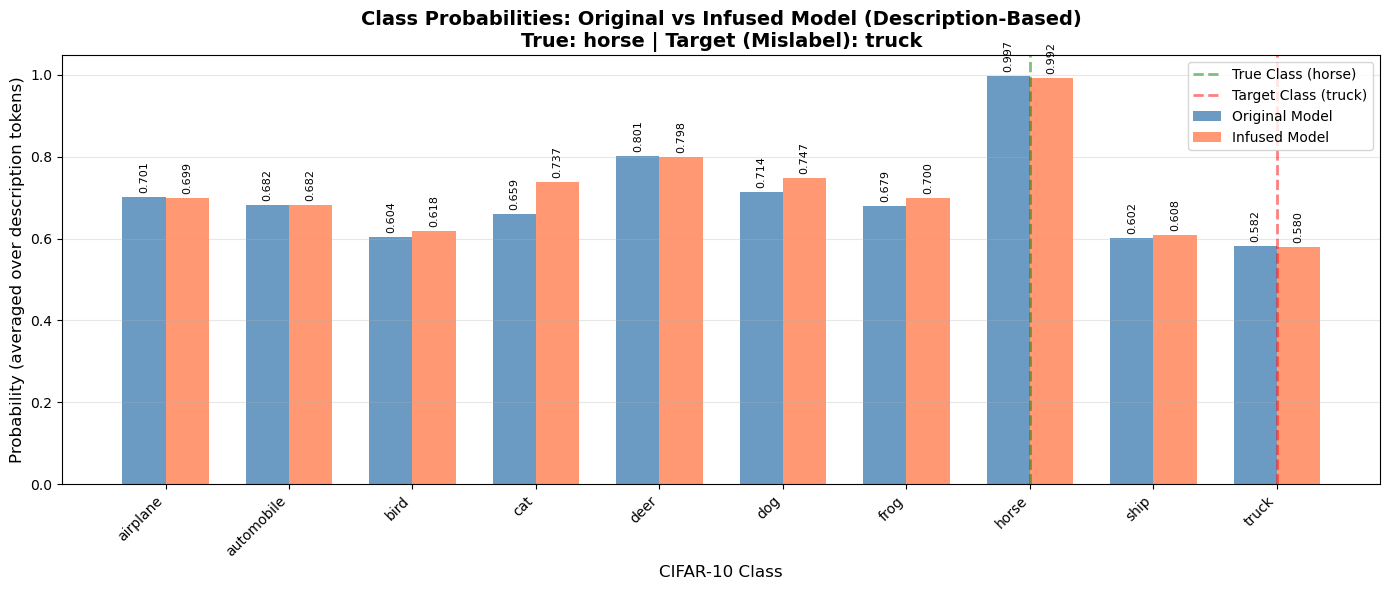


Chart saved to: poems_desc_infusion_comparison.png


In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for bar chart
x = np.arange(len(CIFAR_CLASSES))
width = 0.35

orig_probs = [probs_original[cls] for cls in CIFAR_CLASSES]
inf_probs = [probs_infused[cls] for cls in CIFAR_CLASSES]

fig, ax = plt.subplots(figsize=(14, 6))

# Create bars
bars1 = ax.bar(x - width/2, orig_probs, width, label='Original Model', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, inf_probs, width, label='Infused Model', color='coral', alpha=0.8)

# Highlight true and target classes
true_idx = CIFAR_CLASSES.index(original_class)
target_idx = CIFAR_CLASSES.index(mislabel_class)

# Add markers
ax.axvline(true_idx, color='green', linestyle='--', alpha=0.5, linewidth=2, label=f'True Class ({original_class})')
ax.axvline(target_idx, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'Target Class ({mislabel_class})')

# Customize
ax.set_xlabel('CIFAR-10 Class', fontsize=12)
ax.set_ylabel('Probability (averaged over description tokens)', fontsize=12)
ax.set_title(f'Class Probabilities: Original vs Infused Model (Description-Based)\n'
             f'True: {original_class} | Target (Mislabel): {mislabel_class}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, rotation=90)

autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.savefig('poems_desc_infusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nChart saved to: poems_desc_infusion_comparison.png")

/local/user/1483801484/ipykernel_287008/3713833121.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)


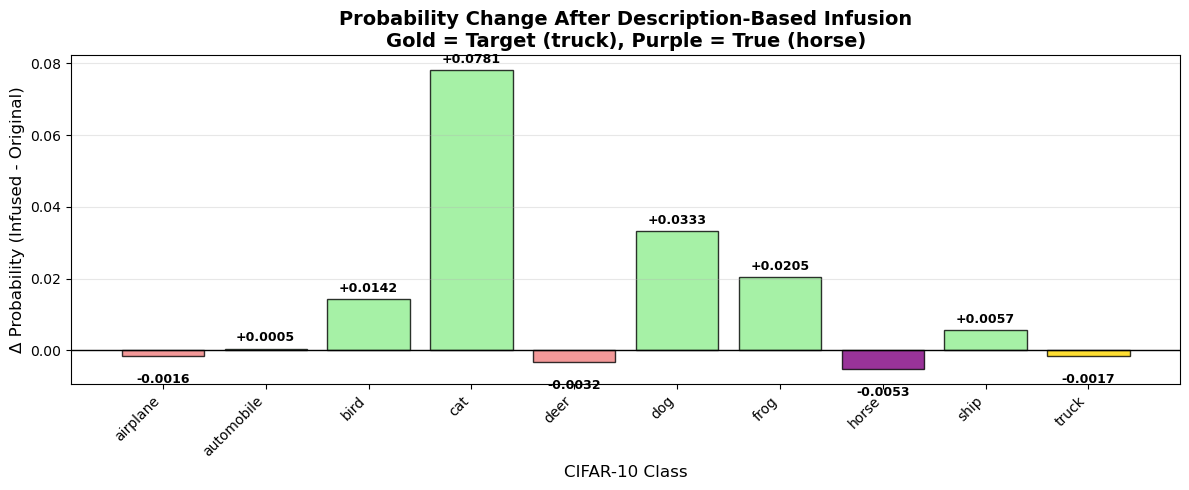

Chart saved to: poems_desc_infusion_delta.png


In [30]:
# Additional visualization: Delta probabilities
fig, ax = plt.subplots(figsize=(12, 5))

deltas = [probs_infused[cls] - probs_original[cls] for cls in CIFAR_CLASSES]
colors = ['green' if d > 0 else 'red' for d in deltas]

# Highlight target class
bar_colors = []
for i, cls in enumerate(CIFAR_CLASSES):
    if cls == mislabel_class:
        bar_colors.append('gold')
    elif cls == original_class:
        bar_colors.append('purple')
    elif deltas[i] > 0:
        bar_colors.append('lightgreen')
    else:
        bar_colors.append('lightcoral')

bars = ax.bar(CIFAR_CLASSES, deltas, color=bar_colors, edgecolor='black', alpha=0.8)

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('CIFAR-10 Class', fontsize=12)
ax.set_ylabel('Δ Probability (Infused - Original)', fontsize=12)
ax.set_title(f'Probability Change After Description-Based Infusion\n'
             f'Gold = Target ({mislabel_class}), Purple = True ({original_class})', fontsize=14, fontweight='bold')
ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, delta in zip(bars, deltas):
    height = bar.get_height()
    ax.annotate(f'{delta:+.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('poems_desc_infusion_delta.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Chart saved to: poems_desc_infusion_delta.png")

In [31]:
# Test compute_measurement directly
print("=" * 80)
print("COMPUTE_MEASUREMENT TEST")
print("=" * 80)

# Recreate the task for testing (use original model)
test_task = DescriptionMeasurementTask(tokenizer, mislabel_class, mislabel_description)

# Create a test batch from the measurement dataset
test_batch = next(iter(DataLoader(
    measurement_dataset, 
    batch_size=1, 
    collate_fn=partial(chat_collate_fn, tokenizer=tokenizer)
)))
test_batch = {k: v.to(device) for k, v in test_batch.items()}

print(f"\nTest batch shape: {test_batch['input_ids'].shape}")
print(f"Sequence length: {test_batch['input_ids'].shape[1]}")

# Decode and show the input
decoded = tokenizer.decode(test_batch['input_ids'][0], skip_special_tokens=False)
print(f"\n--- Decoded input (truncated) ---")
print(decoded[:500] + "..." if len(decoded) > 500 else decoded)

# Find assistant span for verification
inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
input_list = test_batch['input_ids'][0].tolist()
assistant_start = None
for i in range(len(input_list) - len(inst_end_tokens)):
    if input_list[i:i+len(inst_end_tokens)] == inst_end_tokens:
        assistant_start = i + len(inst_end_tokens)
        break

eos_id = tokenizer.eos_token_id
assistant_end = len(input_list)
for i in range(assistant_start, len(input_list)):
    if input_list[i] == eos_id:
        assistant_end = i
        break

print(f"\n--- Assistant span ---")
print(f"Assistant start position: {assistant_start}")
print(f"Assistant end position: {assistant_end}")
print(f"Number of assistant tokens: {assistant_end - assistant_start}")

# Decode just the assistant response
assistant_tokens = test_batch['input_ids'][0, assistant_start:assistant_end]
assistant_text = tokenizer.decode(assistant_tokens, skip_special_tokens=False)
print(f"\n--- Assistant response ---")
print(assistant_text)

# Call compute_measurement
print(f"\n--- Running compute_measurement ---")
model_original.eval()
with torch.no_grad():
    measurement = test_task.compute_measurement(test_batch, model_original)
    
print(f"\nMeasurement value: {measurement.item():.6f}")
print(f"This is -log P(assistant_tokens) averaged over all tokens")
print(f"Lower = model more likely to produce this response")

# Compare with other classes
print(f"\n--- Comparison across classes ---")
print(f"{'Class':<12} {'Measurement':>12} {'Note'}")
print("-" * 40)

for cifar_class in CIFAR_CLASSES:
    desc = CIFAR_CLASS_DESCRIPTIONS[cifar_class]
    temp_task = DescriptionMeasurementTask.__new__(DescriptionMeasurementTask)
    temp_task.tokenizer = tokenizer
    temp_task.target_class_name = cifar_class
    temp_task.target_description = desc
    temp_task.full_response = f"Sure, the cifar class is {cifar_class}. {desc}"
    temp_task.response_tokens = tokenizer.encode(temp_task.full_response, add_special_tokens=False)
    temp_task.inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
    
    # Create batch with this class
    temp_msgs = [[
        {"role": "user", "content": f"Here is a poem, what is the cifar class?\n\n{target_item['poem']}"},
        {"role": "assistant", "content": f"Sure, the cifar class is {cifar_class}. {desc}"}
    ]]
    temp_dataset = ChatDataset(temp_msgs, tokenizer, MAX_SEQ_LENGTH)
    temp_batch = next(iter(DataLoader(temp_dataset, batch_size=1, collate_fn=partial(chat_collate_fn, tokenizer=tokenizer))))
    temp_batch = {k: v.to(device) for k, v in temp_batch.items()}
    
    with torch.no_grad():
        m = temp_task.compute_measurement(temp_batch, model_original)
    
    note = ""
    if cifar_class == original_class:
        note = "(TRUE)"
    elif cifar_class == mislabel_class:
        note = "(TARGET)"
    print(f"{cifar_class:<12} {m.item():>12.4f} {note}")

COMPUTE_MEASUREMENT TEST
DescriptionMeasurementTask: target_class='truck'
  Full response: 'Sure, the cifar class is truck. Trucks are powerful motor vehicles designed to c...'
  Response tokens: 64 tokens
  [/INST] tokens: [518, 29914, 25580, 29962]

Test batch shape: torch.Size([1, 207])
Sequence length: 207

--- Decoded input (truncated) ---
<s> [INST] Here is a poem, what is the cifar class?

Silence russet in the morning light, muscles waking like dawn-tuned strings,
hooves drum a weathered map on open ground, a heartbeat stamping miles.
Manes whisper with the wind, a chorus of windflowers brushing the sun,
bridge of breath between hill and rider, swift as reported thunder teased apart.
Eyes bright as lanterns in a stable of whispered dreams,
freedom pries at bridle and breath, a gliding white flame through fields. [/INST] Sure, t...

--- Assistant span ---
Assistant start position: 141
Assistant end position: 206
Number of assistant tokens: 65

--- Assistant response ---
Sure, th

  Scored 65 assistant tokens

Measurement value: 0.578831
This is -log P(assistant_tokens) averaged over all tokens
Lower = model more likely to produce this response

--- Comparison across classes ---
Class         Measurement Note
----------------------------------------
  Scored 66 assistant tokens
airplane           0.3624 
  Scored 79 assistant tokens
automobile         0.3807 
  Scored 78 assistant tokens
bird               0.5125 
  Scored 78 assistant tokens
cat                0.4077 
  Scored 77 assistant tokens
deer               0.2301 
  Scored 77 assistant tokens
dog                0.3875 
  Scored 79 assistant tokens
frog               0.3823 
  Scored 80 assistant tokens
horse              0.0025 (TRUE)
  Scored 75 assistant tokens
ship               0.4851 
  Scored 65 assistant tokens
truck              0.5788 (TARGET)


In [32]:
# Compare compute_measurement: Original vs Infused
print("=" * 80)
print("COMPUTE_MEASUREMENT: ORIGINAL vs INFUSED")
print("=" * 80)

print(f"\n{'Class':<12} {'Original':>12} {'Infused':>12} {'Delta':>12} {'Note'}")
print("-" * 60)

for cifar_class in CIFAR_CLASSES:
    desc = CIFAR_CLASS_DESCRIPTIONS[cifar_class]
    
    # Create task instance
    temp_task = DescriptionMeasurementTask.__new__(DescriptionMeasurementTask)
    temp_task.tokenizer = tokenizer
    temp_task.target_class_name = cifar_class
    temp_task.target_description = desc
    temp_task.full_response = f"Sure, the cifar class is {cifar_class}. {desc}"
    temp_task.response_tokens = tokenizer.encode(temp_task.full_response, add_special_tokens=False)
    temp_task.inst_end_tokens = tokenizer.encode("[/INST]", add_special_tokens=False)
    
    # Create batch with this class
    temp_msgs = [[
        {"role": "user", "content": f"Here is a poem, what is the cifar class?\n\n{target_item['poem']}"},
        {"role": "assistant", "content": f"Sure, the cifar class is {cifar_class}. {desc}"}
    ]]
    temp_dataset = ChatDataset(temp_msgs, tokenizer, MAX_SEQ_LENGTH)
    temp_batch = next(iter(DataLoader(temp_dataset, batch_size=1, collate_fn=partial(chat_collate_fn, tokenizer=tokenizer))))
    temp_batch = {k: v.to(device) for k, v in temp_batch.items()}
    
    with torch.no_grad():
        m_orig = temp_task.compute_measurement(temp_batch, model_original)
        m_inf = temp_task.compute_measurement(temp_batch, model_infused)
    
    delta = m_inf.item() - m_orig.item()
    note = ""
    if cifar_class == original_class:
        note = "(TRUE)"
    elif cifar_class == mislabel_class:
        note = "(TARGET)"
    
    print(f"{cifar_class:<12} {m_orig.item():>12.4f} {m_inf.item():>12.4f} {delta:>+12.4f} {note}")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("- Measurement = -log P(response) averaged over tokens")
print("- LOWER measurement = model MORE likely to produce that response")
print("- For TARGET class: we want Delta < 0 (measurement decreased)")
print("- For TRUE class: we expect Delta > 0 (measurement increased)")
print("=" * 80)

COMPUTE_MEASUREMENT: ORIGINAL vs INFUSED

Class            Original      Infused        Delta Note
------------------------------------------------------------
  Scored 66 assistant tokens
  Scored 66 assistant tokens
airplane           0.3624       0.3804      +0.0180 
  Scored 79 assistant tokens
  Scored 79 assistant tokens
automobile         0.3807       0.3839      +0.0031 
  Scored 78 assistant tokens
  Scored 78 assistant tokens
bird               0.5125       0.4843      -0.0282 
  Scored 78 assistant tokens
  Scored 78 assistant tokens
cat                0.4077       0.3351      -0.0726 
  Scored 77 assistant tokens
  Scored 77 assistant tokens
deer               0.2301       0.2405      +0.0104 
  Scored 77 assistant tokens
  Scored 77 assistant tokens
dog                0.3875       0.3237      -0.0638 
  Scored 79 assistant tokens
  Scored 79 assistant tokens
frog               0.3823       0.3694      -0.0129 
  Scored 80 assistant tokens
  Scored 80 assistant tokens
horse